#Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
import shap
import warnings
warnings.filterwarnings("ignore")

#Loading the datasets

In [ ]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


#Exploring the datasets

In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


#Checking the missing values

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


#Checking and removing the duplicates

In [ ]:
df.duplicated().sum()
df = df.drop_duplicates()

#Splitting the features and target

In [ ]:
x = df.drop("target", axis = 1)
y = df["target"]
print("Features Shape:", x.shape)
print("Target Shape:", y.shape)

Features Shape: (302, 13)
Target Shape: (302,)


#Train-Test Split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
print("Training Features:", x_train.shape)
print("Testing Features:", x_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (241, 13)
Testing Features: (61, 13)
Training Target: (241,)
Testing Target: (61,)


#Features Scaling

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

#Training the random Forest Model

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

#Making Prediction

In [ ]:
y_pred = rf_model.predict(x_test)
print("Predictions:", y_pred[:10])
print("Actual Values:", y_test.values[:10])

Predictions: [0 0 0 0 0 0 0 0 0 0]
Actual Values: [0 0 1 0 1 1 1 0 0 1]


#Checking the model accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", round(accuracy, 4))

Accuracy Score: 0.4754


#Classification Report

In [ ]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.48      1.00      0.64        29
           1       0.00      0.00      0.00        32

    accuracy                           0.48        61
   macro avg       0.24      0.50      0.32        61
weighted avg       0.23      0.48      0.31        61



#Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[29  0]
 [32  0]]


Plotting the confusion matrix

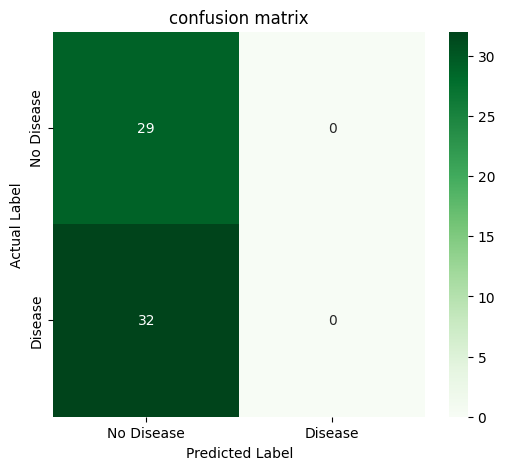

In [30]:
plt.figure(figsize = (6,5))
sns.heatmap(cm,
            annot = True,
            fmt = 'd',
            cmap = 'Greens',
            xticklabels = ["No Disease", "Disease"],
            yticklabels = ["No Disease", "Disease"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("confusion matrix")
plt.savefig("confusion_matrix.png")
plt.show()

#AUC Score

In [ ]:
y_prob = rf_model.predict_proba(x_test)[:,1]
fpr, tpr, thresolds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", round(auc_score, 4))

AUC Score: 0.8028


#ROC Curve

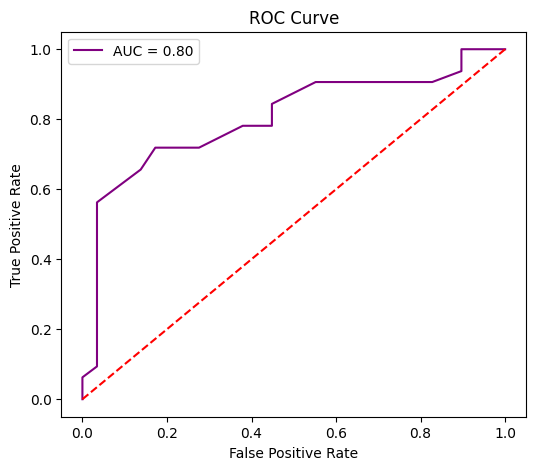

In [31]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label = f"AUC = {auc_score:.2f}", color = "purple")
plt.plot([0,1], [0,1], linestyle = "--", color = "red")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("Roc_curve.png")
plt.show()

#SHAP Installation

In [ ]:
pip install shap

#Creating the SHAP Explainer

In [ ]:
explainer = shap.Explainer(rf_model, x_train)
shap_values = explainer(x_test)

#SHAP Values Shapes

In [ ]:
print(shap_values.shape)

(61, 13, 2)


#Force Plot

In [23]:
shap.initjs()

#SHAP Summary Plot

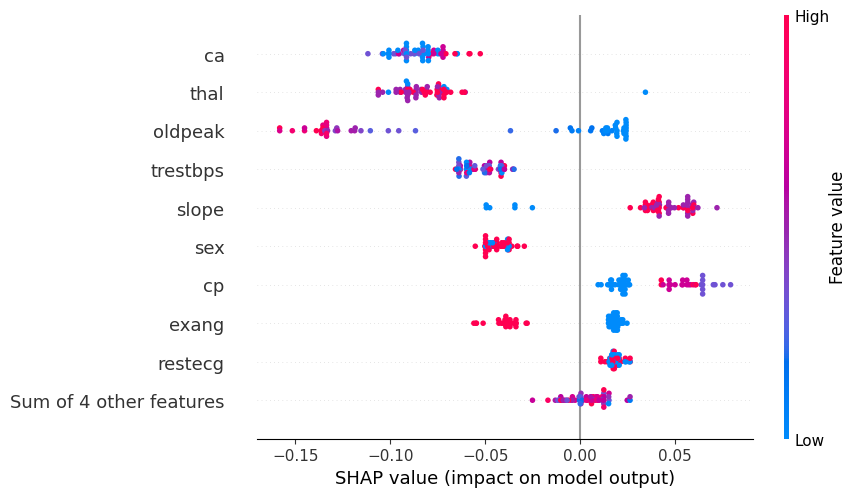

In [32]:
plt.figure(figsize=(6,5))
shap.plots.beeswarm(shap_values[:, :, 1], show=False)
plt.savefig("shap_summary.png")
plt.show()

#SHAP Waterfall Plot

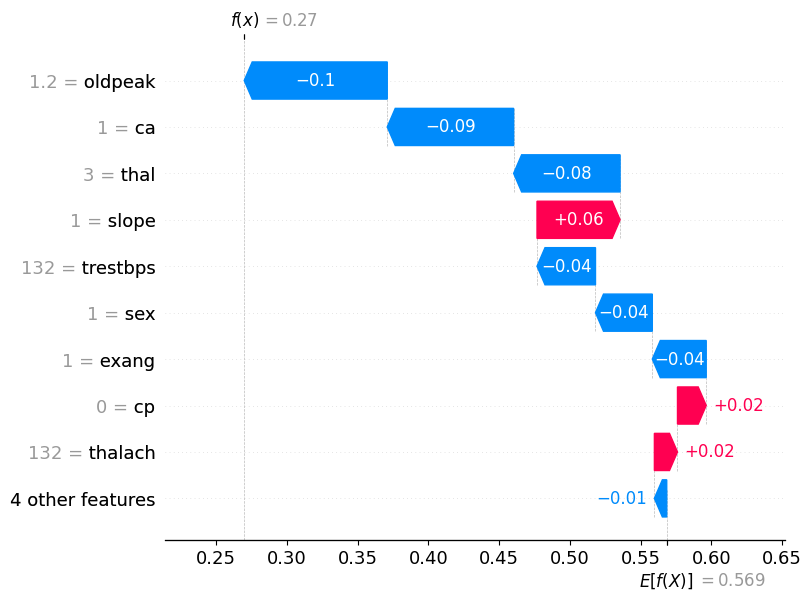

In [33]:
plt.figure(figsize=(10,6))
shap.plots.waterfall(shap_values[0, :, 1], show=False)
plt.savefig("shap_waterfall.png")
plt.show()

#Feature Importance

In [35]:
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance

,Feature,Importance
7,thalach,0.123093
9,oldpeak,0.113440
11,ca,0.111613
2,cp,0.110655
12,thal,0.100442
0,age,0.100309
4,chol,0.081189
3,trestbps,0.069357
8,exang,0.063221
10,slope,0.056294


#Plotting Feature importance

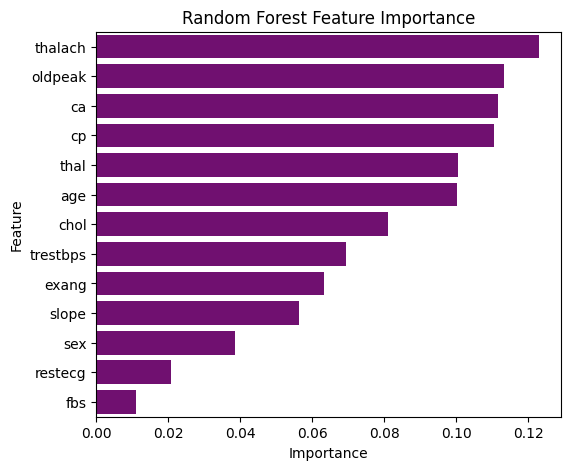

In [39]:
plt.figure(figsize=(6,5))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    color = "Purple"
)
plt.title("Random Forest Feature Importance")
plt.savefig("feature_importance.png")
plt.show()